In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/1) iris.csv')
df.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [5]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
df.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


In [7]:
df.shape

(150, 5)

In [8]:
df.nunique()

,0
sepal_length,35
sepal_width,23
petal_length,43
petal_width,22
species,3


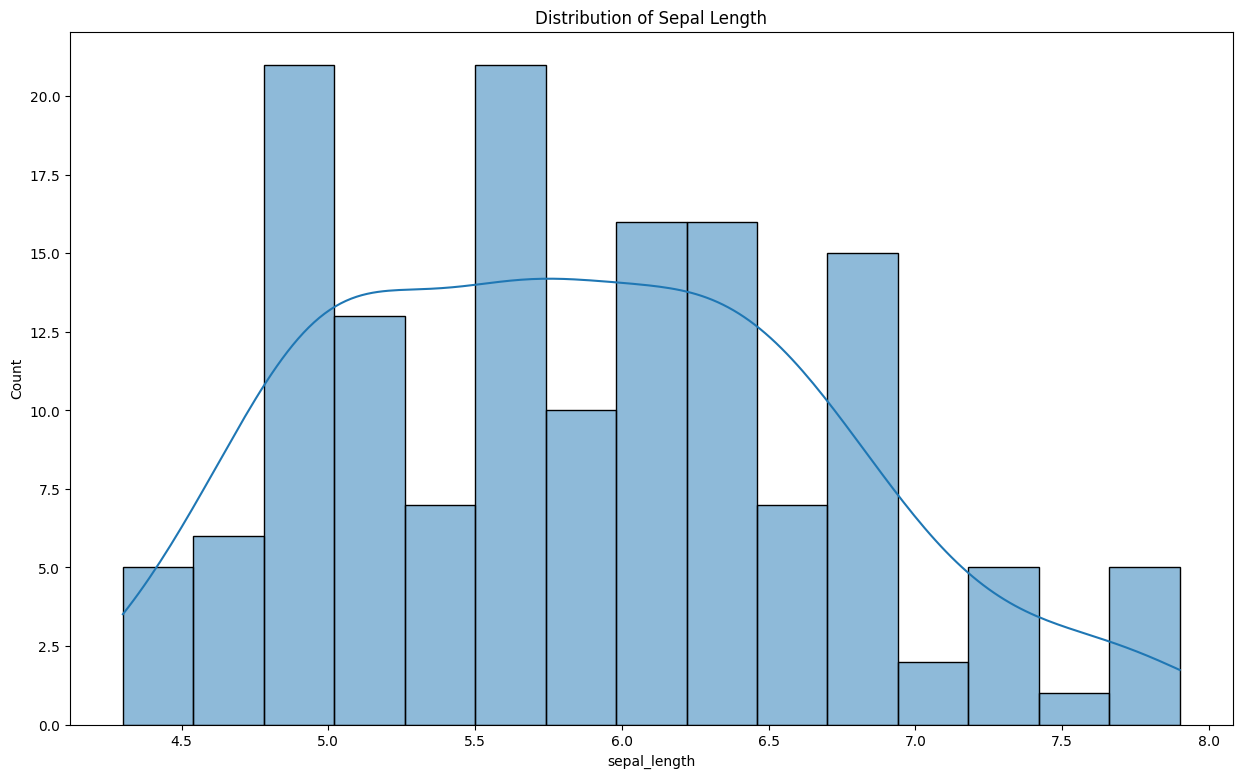

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,9))
sns.histplot(df['sepal_length'], bins=15,kde = True)
plt.title('Distribution of Sepal Length')
plt.show()

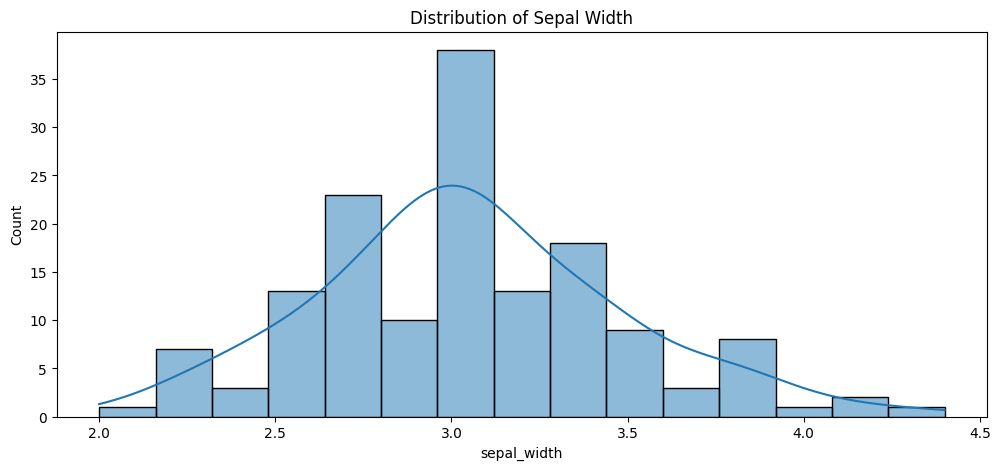

In [10]:
plt.figure(figsize = (12,5))
sns.histplot(df['sepal_width'],bins = 15,kde = True)
plt.title('Distribution of Sepal Width')
plt.show()

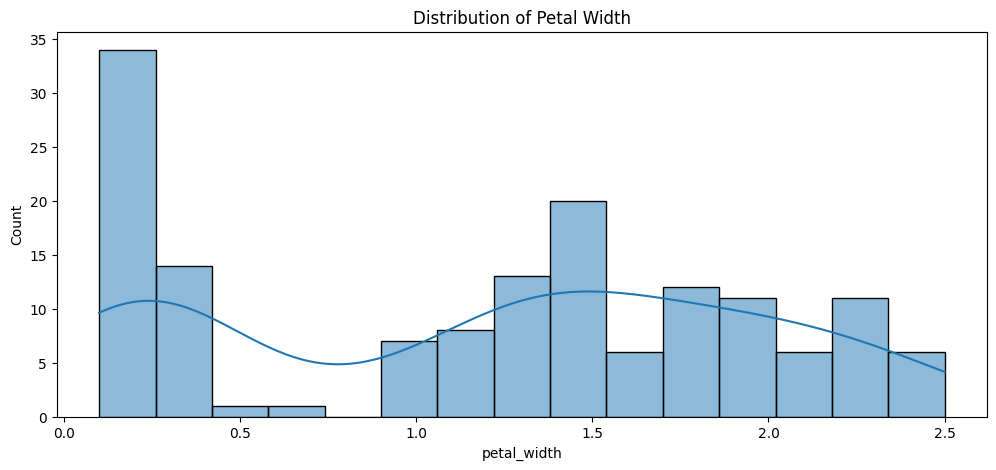

In [11]:
plt.figure(figsize = (12,5))
sns.histplot(df['petal_width'],bins = 15,kde = True)
plt.title('Distribution of Petal Width')
plt.show()

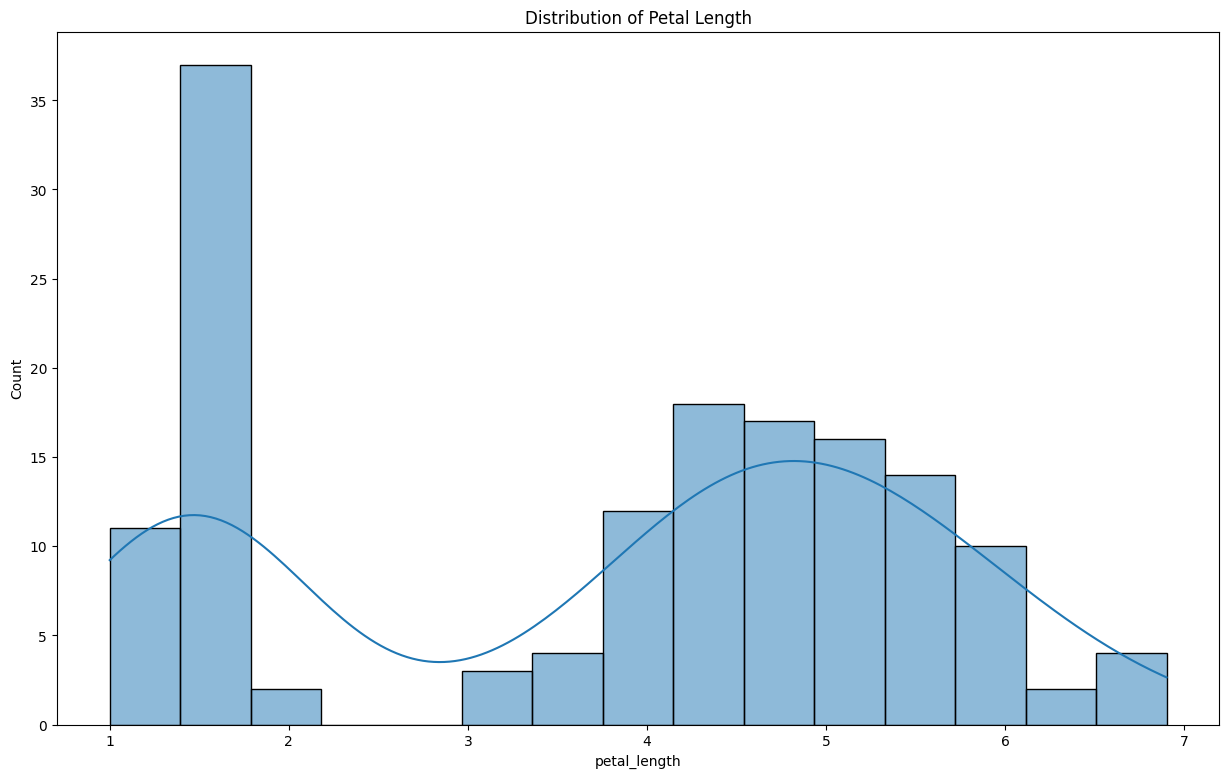

In [12]:
plt.figure(figsize=(15,9))
sns.histplot(df['petal_length'], bins=15,kde = True)
plt.title('Distribution of Petal Length')
plt.show()

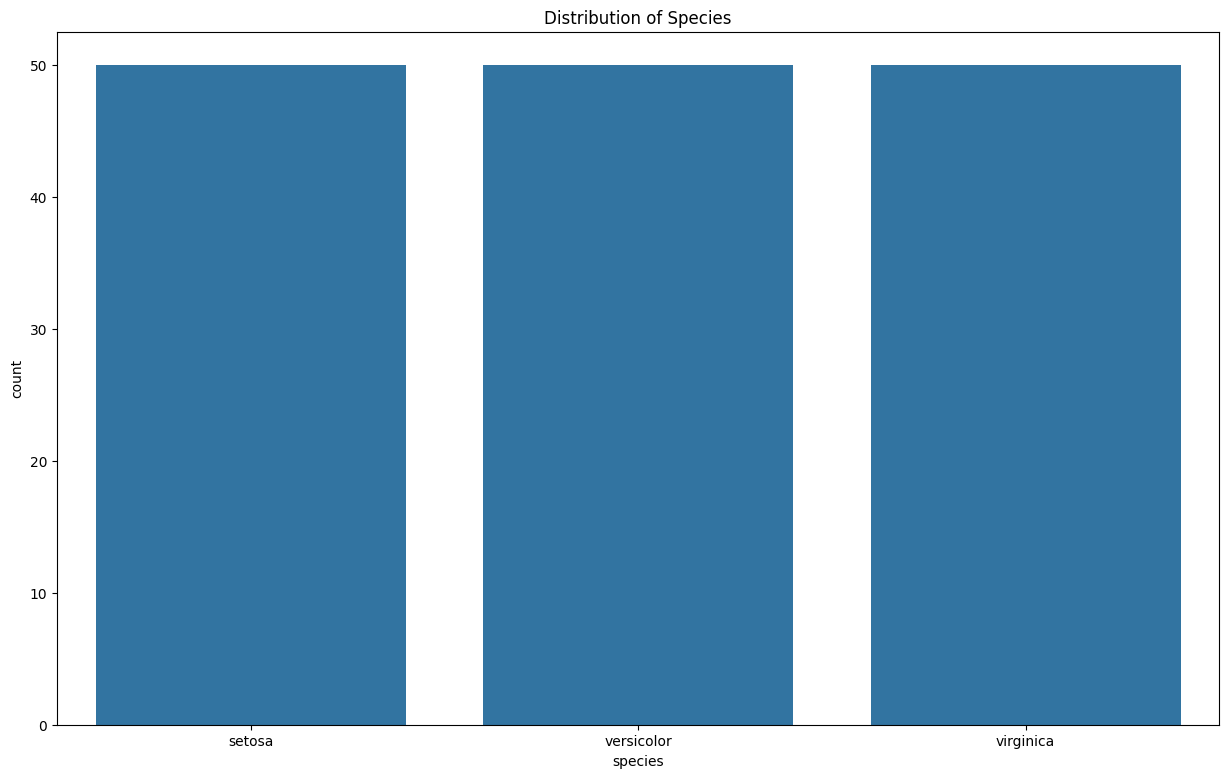

In [13]:
plt.figure(figsize=(15,9))
sns.countplot(x = 'species',data = df)
plt.title('Distribution of Species')
plt.show()

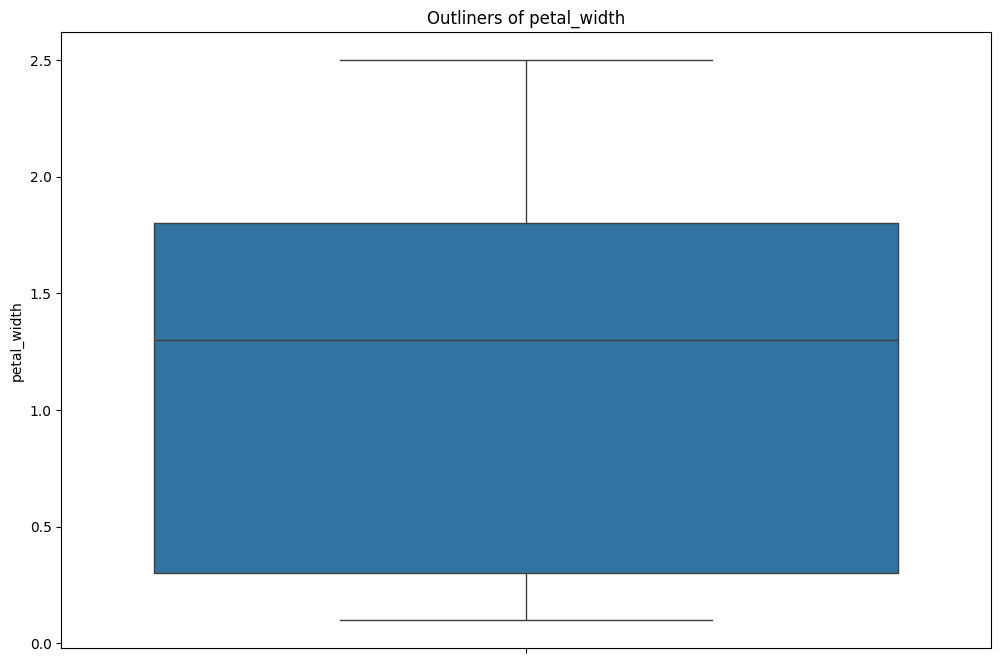

In [15]:
plt.figure(figsize = (12,8))
sns.boxplot(df['petal_width'])
plt.title('Outliners of petal_width')
plt.show()

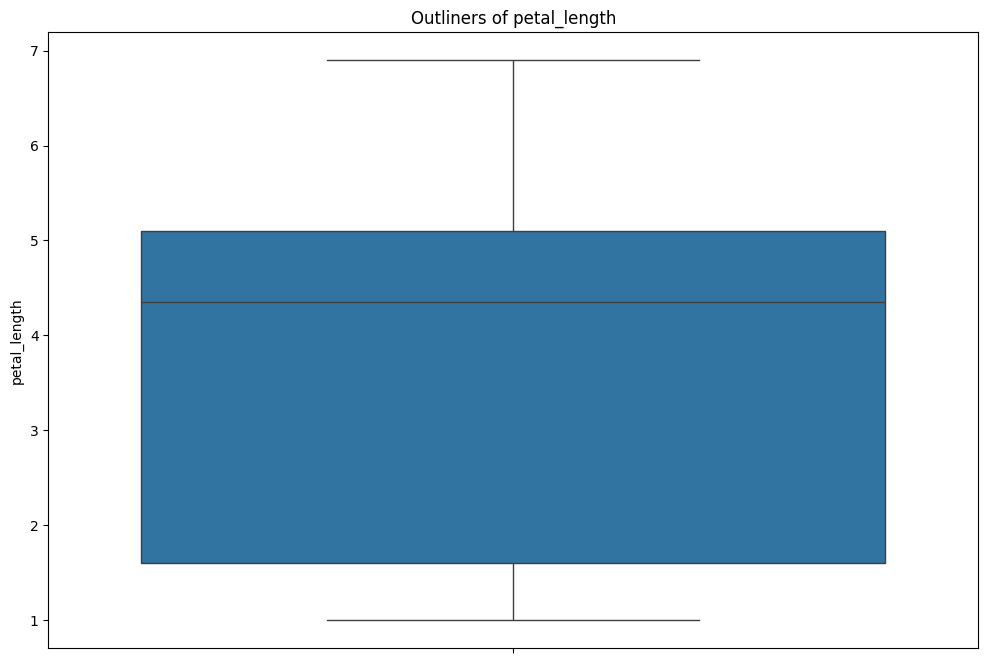

In [16]:
plt.figure(figsize = (12,8))
sns.boxplot(df['petal_length'])
plt.title('Outliners of petal_length')
plt.show()

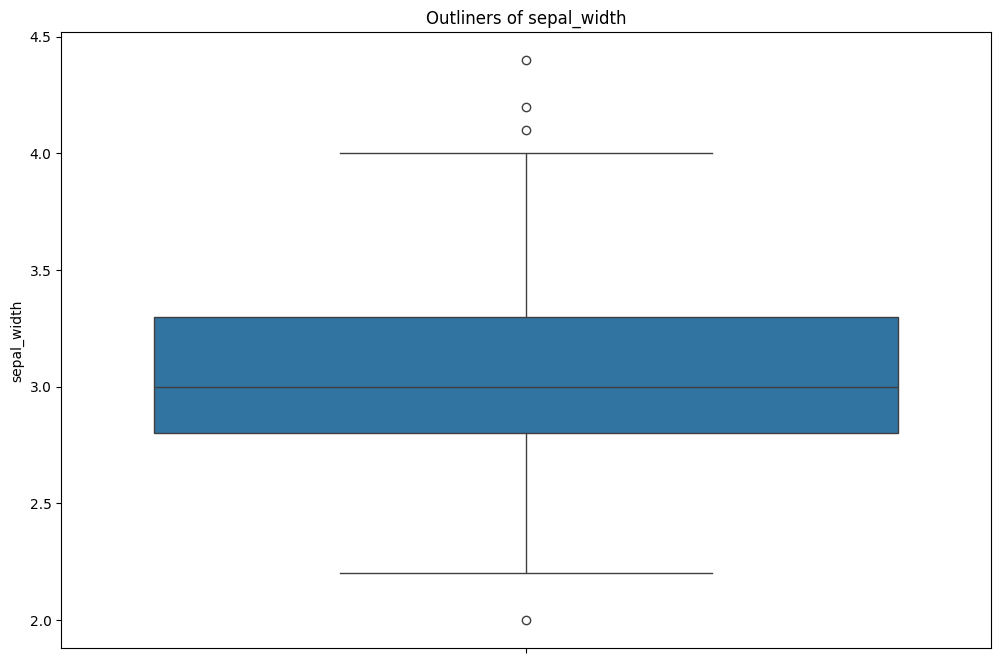

In [17]:
plt.figure(figsize = (12,8))
sns.boxplot(df['sepal_width'])
plt.title('Outliners of sepal_width')
plt.show()

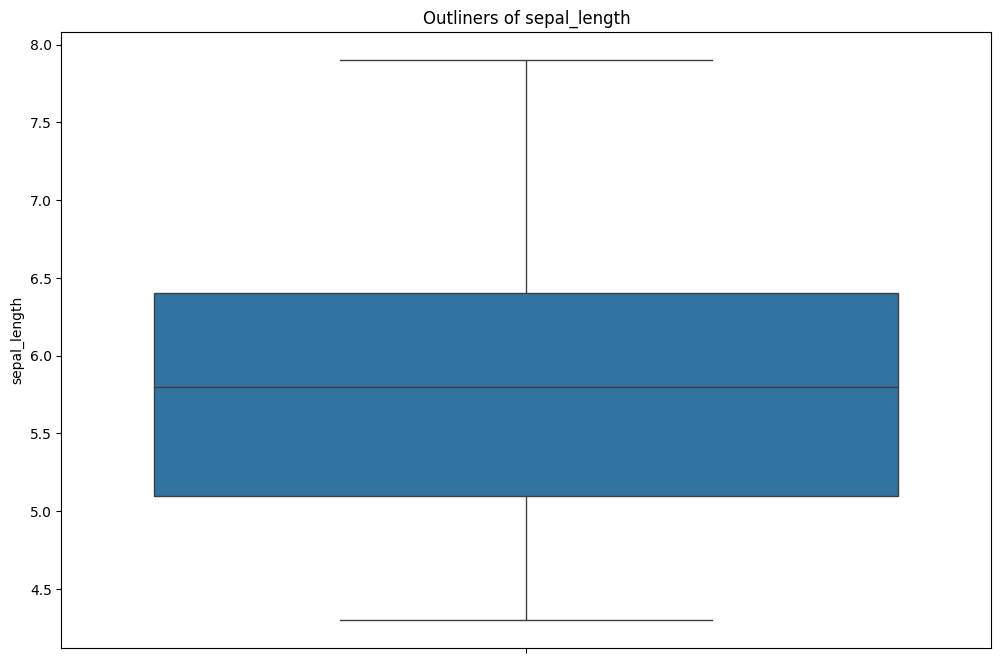

In [18]:
plt.figure(figsize = (12,8))
sns.boxplot(df['sepal_length'])
plt.title('Outliners of sepal_length')
plt.show()

In [19]:
Q1 = df['sepal_width'].quantile(0.25)
Q3 = df['sepal_width'].quantile(0.75)
IQR  = Q3 - Q1
lower =  Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df['sepal_width'] = df['sepal_width'].clip(lower = lower,upper = upper)

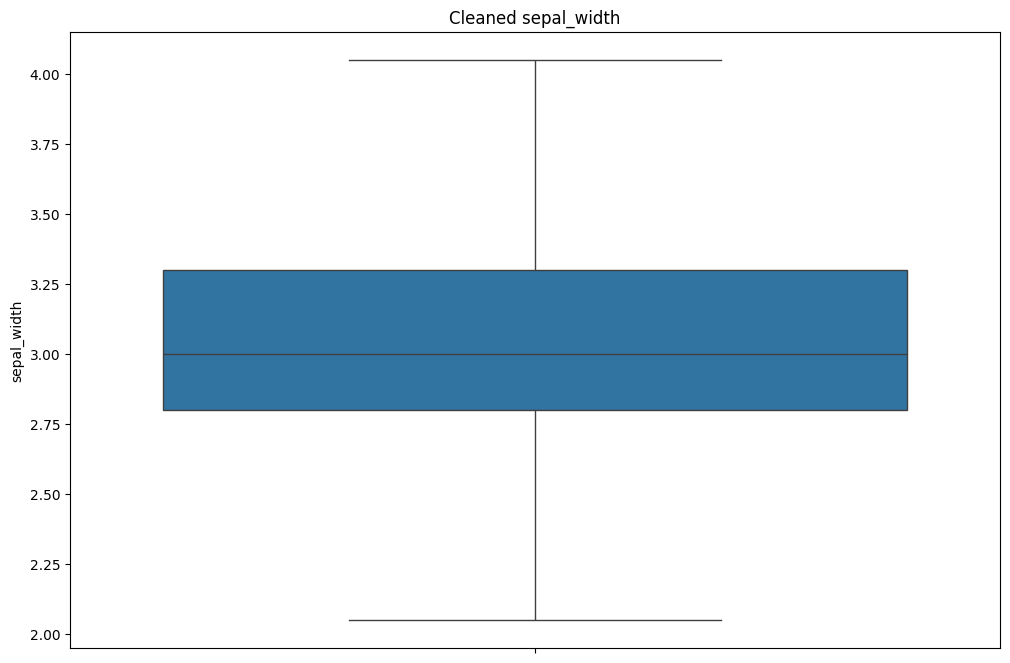

In [20]:
plt.figure(figsize = (12,8))
sns.boxplot(df['sepal_width'])
plt.title('Cleaned sepal_width')
plt.show()

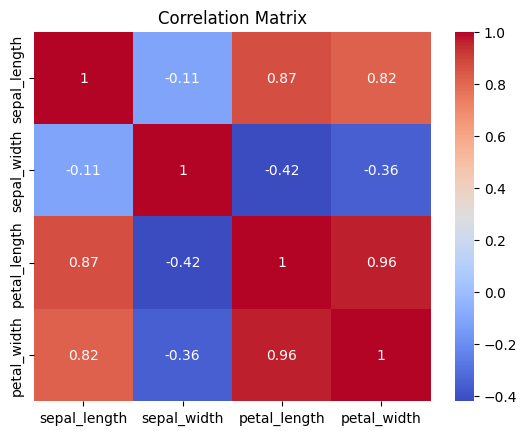

In [21]:
sns.heatmap(df.corr(numeric_only= True), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

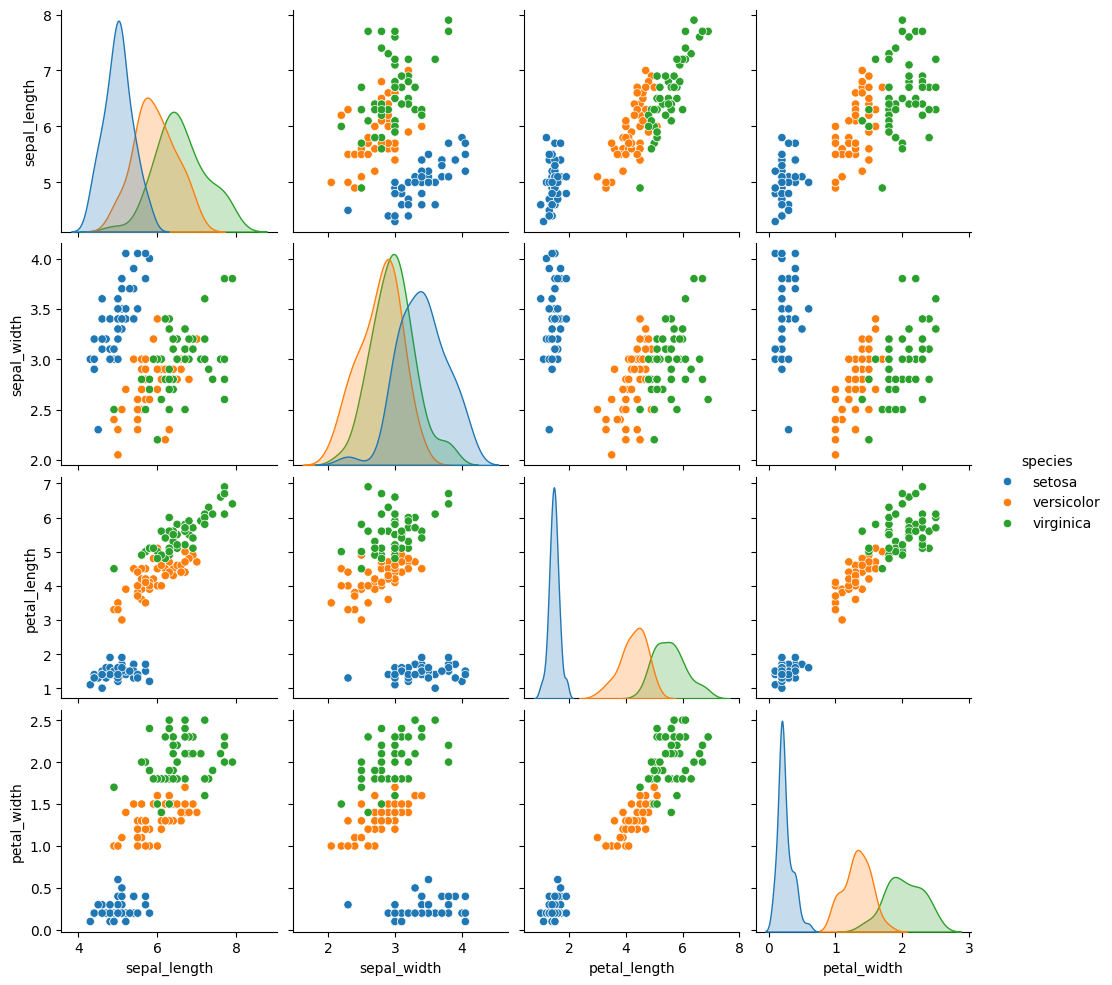

In [22]:
sns.pairplot(df,hue = 'species',diag_kind = 'kde')
plt.show()

In [23]:
from sklearn.preprocessing import StandardScaler

features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

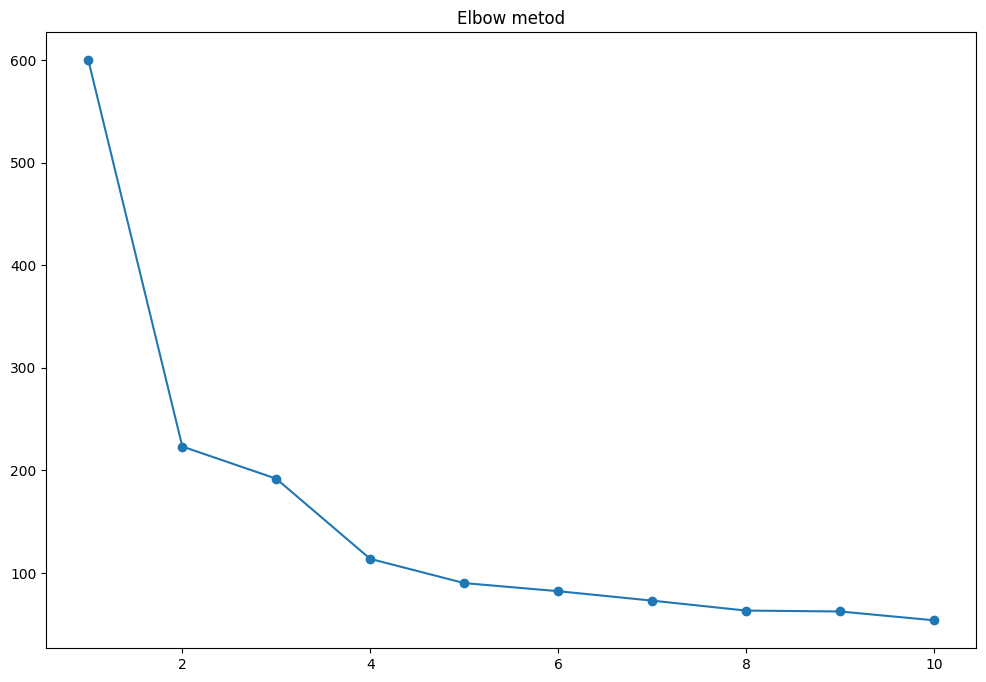

In [24]:
from sklearn.cluster import KMeans
inertia = []

K = range(1,11)
for k in K:
  model = KMeans(n_clusters= k,random_state= 42)
  model.fit(X_scaled)
  inertia.append(model.inertia_)
plt.figure(figsize = (12,8))
plt.plot(K,inertia,marker = 'o')
plt.title('Elbow metod')
plt.show()



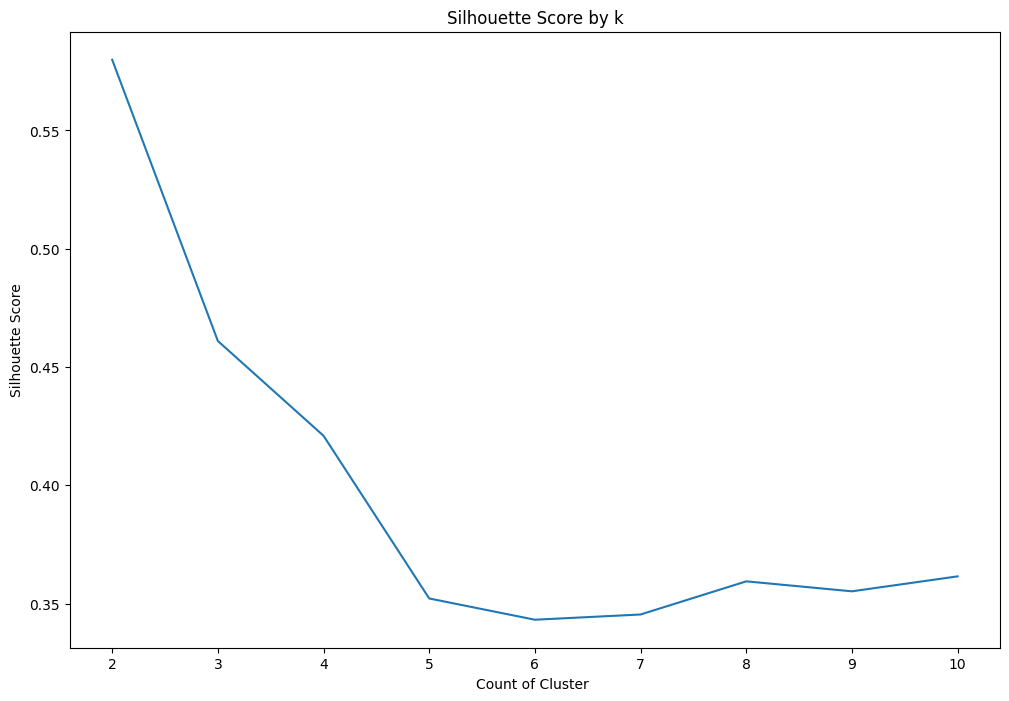

In [25]:
from sklearn.metrics import silhouette_score
silhouette_scores = []
k_range = range(2,11)
for k in k_range:
  km = KMeans(n_clusters = k,random_state = 42,n_init = 10)
  label = km.fit_predict(X_scaled)
  score = silhouette_score(X_scaled,label)
  silhouette_scores.append(score)
plt.figure(figsize = (12,8))
plt.plot(k_range,silhouette_scores)
plt.xlabel('Count of Cluster ')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by k')
plt.show()


In [26]:
final_kmeans = KMeans(n_clusters = 3,random_state = 42,n_init = 10)
df['Cluster'] =  final_kmeans.fit_predict(X_scaled)
print(df['Cluster'].value_counts())


Cluster
0    53
1    50
2    47
Name: count, dtype: int64


In [27]:
centroid = final_kmeans.cluster_centers_
centroid_original = scaler.inverse_transform(centroid)
centroid_df = pd.DataFrame(centroid_original,columns = features)
centroid_df.index.name = 'cluster'
print(centroid_df)

         sepal_length  sepal_width  petal_length  petal_width
cluster                                                      
0            5.801887     2.674528      4.369811     1.413208
1            5.006000     3.407000      1.464000     0.244000
2            6.780851     3.095745      5.510638     1.972340


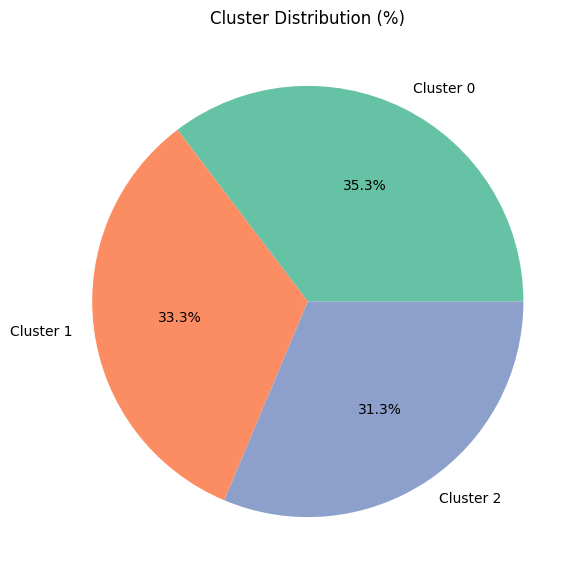

In [31]:
cluster_count = df['Cluster'].value_counts().sort_index()
plt.figure(figsize = (7,7))
plt.pie(cluster_count,labels = [f'Cluster {i}' for i in cluster_count.index],
        autopct = '%1.1f%%',colors = sns.color_palette('Set2'))
plt.title('Cluster Distribution (%)')
plt.show()

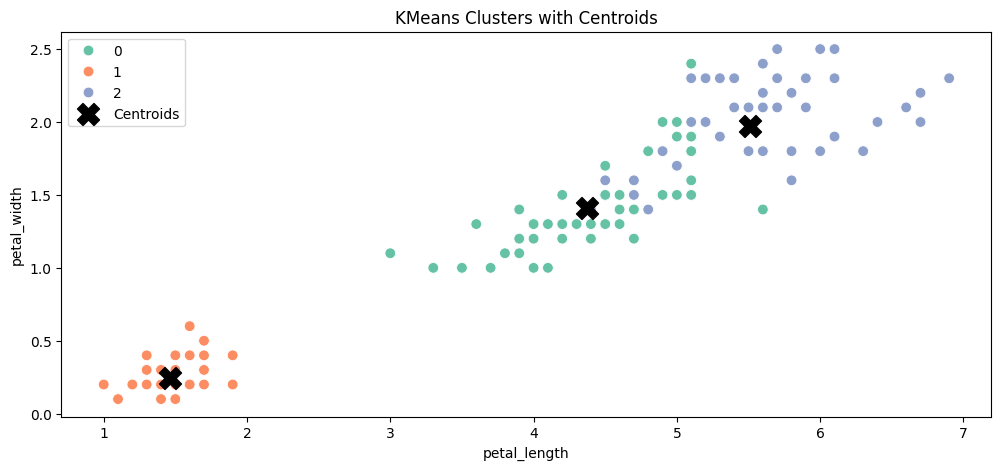

In [36]:
plt.figure(figsize = (12,5))
sns.scatterplot(data = df,x = 'petal_length',y ='petal_width',hue = 'Cluster',palette = 'Set2',s = 60)
plt.scatter(centroid_df['petal_length'],centroid_df['petal_width'],color = 'black',marker = 'X',s = 250,label = 'Centroids')
plt.title('KMeans Clusters with Centroids')
plt.legend()
plt.show()

In [39]:
cross_tab = pd.crosstab(df['species'],df['Cluster'])
print(cross_tab)


Cluster      0   1   2
species               
setosa       0  50   0
versicolor  39   0  11
virginica   14   0  36


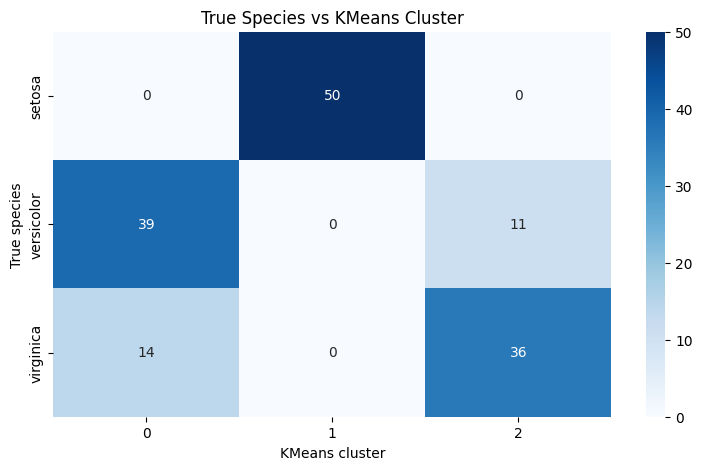

In [42]:
plt.figure(figsize =(9,5))
sns.heatmap(cross_tab,annot = True,fmt = 'd',cmap = 'Blues')
plt.title('True Species vs KMeans Cluster')
plt.ylabel('True species')
plt.xlabel('KMeans cluster')
plt.show()

In [45]:
accuracy = (cross_tab.values.max(axis = 1).sum())/ len(df) * 100
print(f'Overall Model Accuracy:{accuracy:.2f}%')

Overall Model Accuracy:83.33%
